In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

In [57]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
churn_df = pd.read_csv(url)

churn_df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


In [58]:
churn_df = churn_df[['tenure', 'age','wireless','callcard', 'address', 'income', 'ed', 'employ', 'churn']]
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df.head()

C:\Users\pavan b\AppData\Local\Temp\ipykernel_33284\135974747.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  churn_df['churn'] = churn_df['churn'].astype('int')


,tenure,age,wireless,callcard,address,income,ed,employ,churn
0,11.0,33.0,1.0,1.0,7.0,136.0,5.0,5.0,1
1,33.0,33.0,0.0,0.0,12.0,33.0,2.0,0.0,1
2,23.0,30.0,0.0,0.0,9.0,30.0,1.0,2.0,0
3,38.0,35.0,1.0,1.0,5.0,76.0,2.0,10.0,0
4,7.0,35.0,0.0,1.0,14.0,80.0,2.0,15.0,0


In [59]:
X = churn_df[['tenure', 'age','wireless','callcard', 'address', 'income', 'ed', 'employ']]
              
X

,tenure,age,wireless,callcard,address,income,ed,employ
0,11.0,33.0,1.0,1.0,7.0,136.0,5.0,5.0
1,33.0,33.0,0.0,0.0,12.0,33.0,2.0,0.0
2,23.0,30.0,0.0,0.0,9.0,30.0,1.0,2.0
3,38.0,35.0,1.0,1.0,5.0,76.0,2.0,10.0
4,7.0,35.0,0.0,1.0,14.0,80.0,2.0,15.0
...,...,...,...,...,...,...,...,...
195,55.0,44.0,0.0,1.0,24.0,83.0,1.0,23.0
196,34.0,23.0,0.0,1.0,3.0,24.0,1.0,7.0
197,6.0,32.0,0.0,1.0,10.0,47.0,1.0,10.0
198,24.0,30.0,1.0,1.0,0.0,25.0,4.0,5.0


In [60]:
y = churn_df['churn']
y

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    0
198    1
199    0
Name: churn, Length: 200, dtype: int64

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 4)

In [62]:
lr = LogisticRegression().fit(X_train,y_train)

c:\Users\pavan b\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
yhat = lr.predict(X_test)
yhat

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [64]:
np.asarray(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0])

In [65]:
X_norm = StandardScaler().fit(X).transform(X)
X_norm

array([[-1.13518441, -0.62595491,  1.56469673, ...,  0.4751423 ,
         1.6961288 , -0.58477841],
       [-0.11604313, -0.62595491, -0.63910148, ..., -0.32886061,
        -0.6433592 , -1.14437497],
       [-0.57928917, -0.85594447, -0.63910148, ..., -0.35227817,
        -1.42318853, -0.92053635],
       ...,
       [-1.36680743, -0.7026181 , -0.63910148, ..., -0.21957866,
        -1.42318853, -0.02518185],
       [-0.53296457, -0.85594447,  1.56469673, ..., -0.39130744,
         0.91629947, -0.58477841],
       [ 1.18104577,  0.67731925,  1.56469673, ...,  0.89665839,
        -0.6433592 ,  1.31784991]])

In [66]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 4)

In [67]:
lr = LogisticRegression().fit(X_train,y_train)
yhat = lr.predict(X_test)
yhat

c:\Users\pavan b\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [68]:
np.asarray(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0])

In [69]:
yhat_prob = lr.predict_proba(X_test)
yhat_prob[:10]

array([[0.92407208, 0.07592792],
       [0.77624431, 0.22375569],
       [0.6831383 , 0.3168617 ],
       [0.93941763, 0.06058237],
       [0.69680194, 0.30319806],
       [0.80935989, 0.19064011],
       [0.55978018, 0.44021982],
       [0.72393702, 0.27606298],
       [0.40743989, 0.59256011],
       [0.8105846 , 0.1894154 ]])

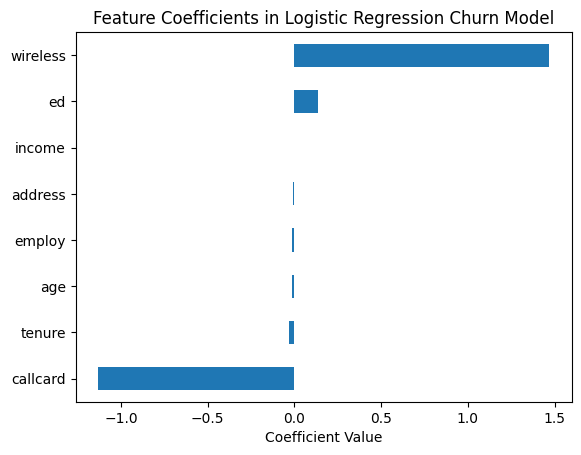

In [70]:
coefficients = pd.Series(lr.coef_[0],index = churn_df.columns[:-1])
coefficients.sort_values().plot(kind = 'barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

In [71]:
log_loss(y_test,yhat_prob)

0.6308590350503824